<h1>Tarea 10: Predicción del precio de autos</h1>
<p>Jose Luis Romero Vazquez<p>
15/Julio/2023

***1. Cargue los datos en Python usando Pandas y muestre los primeros 10 registros***

In [ ]:
# ==============================================================================
import pandas as pd
import numpy as np



# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns; sns.set()



# Preprocesado y modelado
# ==============================================================================
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats



# Configuración matplotlib
# ==============================================================================
plt.rcParams['image.cmap'] = "bwr"
#plt.rcParams['figure.dpi'] = "100"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')
plt.style.use('tableau-colorblind10')
sns.set_style('whitegrid')



# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')
dataframe = pd.read_csv(r"CarPrice_Assignment.csv")
print(dataframe.head(10))

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   
5       6          2                  audi fox      gas        std        two   
6       7          1                audi 100ls      gas        std       four   
7       8          1                 audi 5000      gas        std       four   
8       9          1                 audi 4000      gas      turbo       four   
9      10          0       audi 5000s (diesel)      gas      turbo        two   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          f

**2. Muestre las dimensiones del dataframe (# renglones, #columnas)**

In [ ]:
dataframe.size

5330

In [ ]:
dataframe.shape

(205, 26)

**3. Las columnas doornumber y cylindernumber tienen su valor con letra en inglés.
Convierta su valor a numérico con el siguiente código:**

In [ ]:
numbers=['zero','one','two','three','four','five','six','seven','eight']
i=0
while i<9:
 dataframe["doornumber"].replace(numbers[i],i,inplace=True)
 dataframe["cylindernumber"].replace(numbers[i],i,inplace=True)
 i=i+1
dataframe["cylindernumber"].replace("twelve",12,inplace=True)
dataframe[["doornumber","cylindernumber"]].head(5)

,doornumber,cylindernumber
0,2,4
1,2,4
2,2,6
3,4,4
4,4,5


**4. Muestre las estadísticas (media, desv est, cuartiles, max) y el número de valores
faltantes del dataframe**

In [ ]:
media = dataframe.mean()
p90 = dataframe.quantile([0.25, 0.5,0.75])
std1 = dataframe.std(ddof=0)
var1 = dataframe.var(ddof=0)
max1= dataframe.max
na=dataframe.isna()

print("media")
print(media)
print("cuartile")
print(p90)
print("desviacion estandar")
print(std1)
print("varianza")
print(var1)
print("Max")
print(max1)
print("Na")
print(na)


media
car_ID                103.000000
symboling               0.834146
doornumber              3.121951
wheelbase              98.756585
carlength             174.049268
carwidth               65.907805
carheight              53.724878
curbweight           2555.565854
cylindernumber          4.380488
enginesize            126.907317
boreratio               3.329756
stroke                  3.255415
compressionratio       10.142537
horsepower            104.117073
peakrpm              5125.121951
citympg                25.219512
highwaympg             30.751220
price               13276.710571
dtype: float64
cuartile
      car_ID  symboling  doornumber  wheelbase  carlength  carwidth  \
0.25    52.0        0.0         2.0       94.5      166.3      64.1   
0.50   103.0        1.0         4.0       97.0      173.2      65.5   
0.75   154.0        2.0         4.0      102.4      183.1      66.9   

      carheight  curbweight  cylindernumber  enginesize  boreratio  stroke  \
0.25       52

**5. Muestre todas las características (columnas) que posee el dataframe indicando su
tipo**

In [ ]:
dataframe.dtypes

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber            int64
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber        int64
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

**6. Verifique que no hay renglones duplicados**

In [ ]:
dataframe.duplicated().sum()

0

**7. Realice el histograma y el diagrama de bigotes del precio**

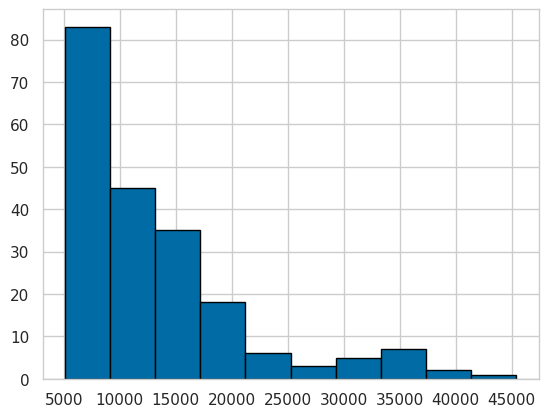

Primer cuartil:		 7788.0
Mediana:		 10295.0
Tercer cuartil:		 16503.0
Rango intercuartil:	 8715.0
Valor mínimo:		 5118.0
Valor máximo:		 45400.0
Bigote inferior:	 -5284.5
Bigote superior:	 29575.5


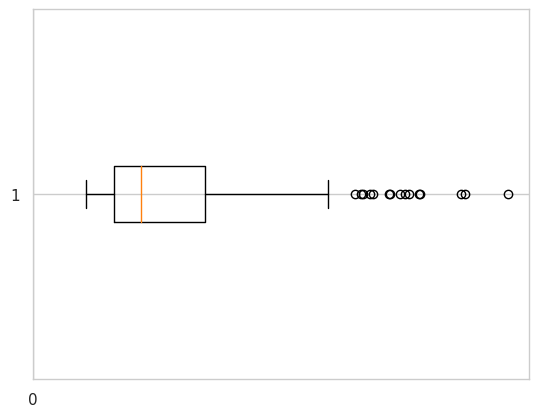

In [ ]:
plt.hist(dataframe["price"],edgecolor="black",linewidth=1)
plt.show()

Q1=dataframe["price"].quantile(0.25)
print("Primer cuartil:\t\t",Q1)
mediana=dataframe["price"].median()
print("Mediana:\t\t",mediana)
Q3=dataframe["price"].quantile(0.75)
print("Tercer cuartil:\t\t",Q3)
IQR=Q3-Q1
print("Rango intercuartil:\t",IQR)
minimo=dataframe["price"].min()
print("Valor mínimo:\t\t",minimo)
maximo=dataframe["price"].max()
print("Valor máximo:\t\t",maximo)

BI=Q1-1.5*IQR
BS=Q3+1.5*IQR
print("Bigote inferior:\t",BI)
print("Bigote superior:\t",BS)

plt.boxplot(dataframe["price"],vert=False)
plt.grid(True)
plt.xticks(np.arange(0,7,60))
plt.show()

**8. Como podrá observar la marca está incluida en el nombre del auto, extráigala con el
siguiente código**

In [ ]:
Company_Name = dataframe["CarName"].apply(lambda x: x.split(" ")[0])
dataframe.insert(2,"CompanyName",Company_Name)
# Now we can drop the CarName Feature.
dataframe.drop(columns=["CarName"],inplace=True)
dataframe.head()

,car_ID,symboling,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi,gas,std,4,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi,gas,std,4,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


**9. Verifique los valores únicos de la marca**

In [ ]:
dataframe["CompanyName"].unique()


array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

**10.Hay algunas marcas con errores por ejemplo maxda y mazda o vw y volkswagen.
Ejecute el siguiente código para solucionarlo:**

In [ ]:
def replace (a, b):
 dataframe["CompanyName"].replace(a, b, inplace=True)
replace('maxda','mazda')
replace('porcshce','porsche')
replace('toyouta','toyota')
replace('vokswagen','volkswagen')
replace('vw','volkswagen')


**11.A partir de la marca y del precio promedio de cada marca agregue una columna que
indique la gama del automóvil (baja, media, alta) con el siguiente código:**

In [ ]:
z = round(dataframe.groupby(["CompanyName"])["price"].agg(["mean"]),2).T
z

CompanyName,Nissan,alfa-romero,audi,bmw,buick,chevrolet,dodge,honda,isuzu,jaguar,...,nissan,peugeot,plymouth,porsche,renault,saab,subaru,toyota,volkswagen,volvo
mean,5499.0,15498.33,17859.17,26118.75,33647.0,6007.0,7875.44,8184.69,8916.5,34600.0,...,10704.88,15489.09,7963.43,31400.5,9595.0,15223.33,8541.25,9885.81,10077.5,18063.18


In [ ]:
df = dataframe.merge(z.T,how="left",on="CompanyName")


In [ ]:
bins = [0,10000,20000,40000]
cars_bin=['Budget','Medium','Highend']
df['CarsRange'] = pd.cut(df['mean'], bins, right=False, labels=cars_bin)
df.head()

,car_ID,symboling,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,mean,CarsRange
0,1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,13495.0,15498.33,Medium
1,2,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,16500.0,15498.33,Medium
2,3,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154,5000,19,26,16500.0,15498.33,Medium
3,4,2,audi,gas,std,4,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102,5500,24,30,13950.0,17859.17,Medium
4,5,2,audi,gas,std,4,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115,5500,18,22,17450.0,17859.17,Medium


**12.Elimine las columnas car_ID, enginelocation y symboling ya que una solo es un
identificador, la ubicación del motor no es importante y la otra no aporta información
valiosa al modelo.**

In [ ]:
df.drop(['car_ID', 'enginelocation', 'symboling'], axis=1)


,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,wheelbase,carlength,carwidth,carheight,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,mean,CarsRange
0,alfa-romero,gas,std,2,convertible,rwd,88.6,168.8,64.1,48.8,...,3.47,2.68,9.0,111,5000,21,27,13495.0,15498.33,Medium
1,alfa-romero,gas,std,2,convertible,rwd,88.6,168.8,64.1,48.8,...,3.47,2.68,9.0,111,5000,21,27,16500.0,15498.33,Medium
2,alfa-romero,gas,std,2,hatchback,rwd,94.5,171.2,65.5,52.4,...,2.68,3.47,9.0,154,5000,19,26,16500.0,15498.33,Medium
3,audi,gas,std,4,sedan,fwd,99.8,176.6,66.2,54.3,...,3.19,3.40,10.0,102,5500,24,30,13950.0,17859.17,Medium
4,audi,gas,std,4,sedan,4wd,99.4,176.6,66.4,54.3,...,3.19,3.40,8.0,115,5500,18,22,17450.0,17859.17,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,4,sedan,rwd,109.1,188.8,68.9,55.5,...,3.78,3.15,9.5,114,5400,23,28,16845.0,18063.18,Medium
201,volvo,gas,turbo,4,sedan,rwd,109.1,188.8,68.8,55.5,...,3.78,3.15,8.7,160,5300,19,25,19045.0,18063.18,Medium
202,volvo,gas,std,4,sedan,rwd,109.1,188.8,68.9,55.5,...,3.58,2.87,8.8,134,5500,18,23,21485.0,18063.18,Medium
203,volvo,diesel,turbo,4,sedan,rwd,109.1,188.8,68.9,55.5,...,3.01,3.40,23.0,106,4800,26,27,22470.0,18063.18,Medium


**13.Realice los histogramas de las columnas categóricas vs Precio junto con los gráficos
de dispersión (scatterplot) de las columnas numéricas vs Precio.**

10295.0


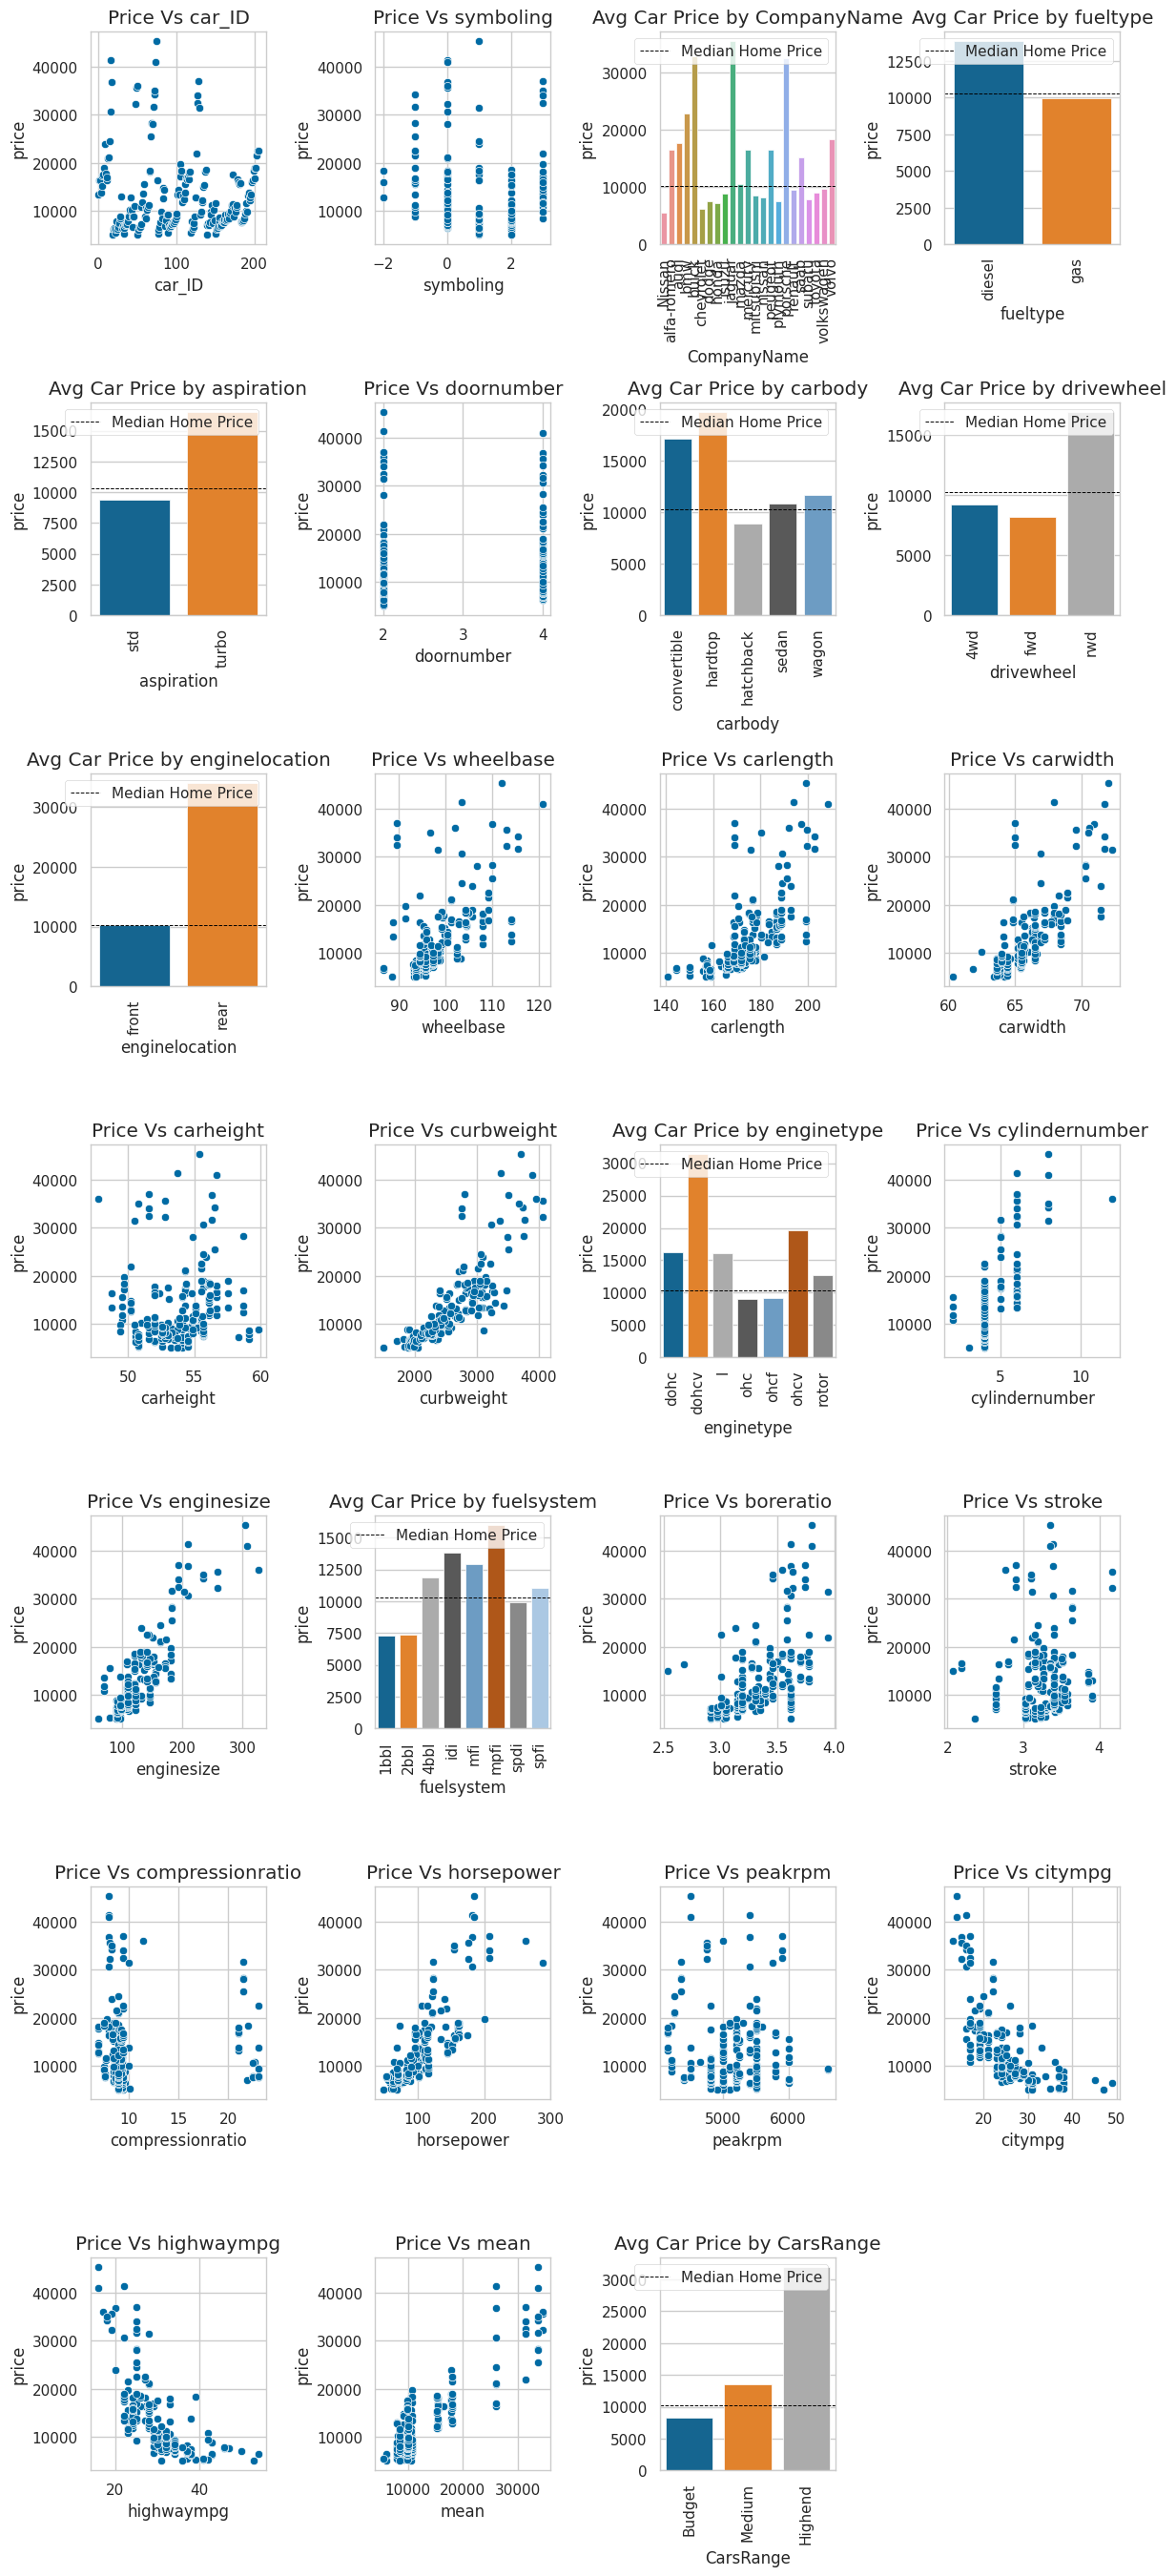

In [ ]:
viz_df = df.copy()

median_home_price = viz_df['price'].median().round(2)

print(median_home_price)

k = 0

plt.figure(figsize=(12, 30))

for col in viz_df.drop('price', axis=1).columns:

    plt.subplot(8, 4, k + 1)

    if viz_df[col].dtype == 'float64' or viz_df[col].dtype =='int':

        sns.scatterplot(data=viz_df, x=col, y='price')

        plt.title(f"Price Vs {col}")

    else:

        group = viz_df[[col, 'price']].groupby(by=col).median()

        sns.barplot(data=group, x=group.index, y='price')

        plt.xticks(rotation=90)

        plt.axhline(y=median_home_price, label='Median Home Price', color='black', linestyle='--', linewidth=0.7)

        plt.title(f"Avg Car Price by {col}")

        plt.legend()

    k += 1

plt.tight_layout()

**14.Realice el diagrama de bigotes del precio respecto las siguientes características:**

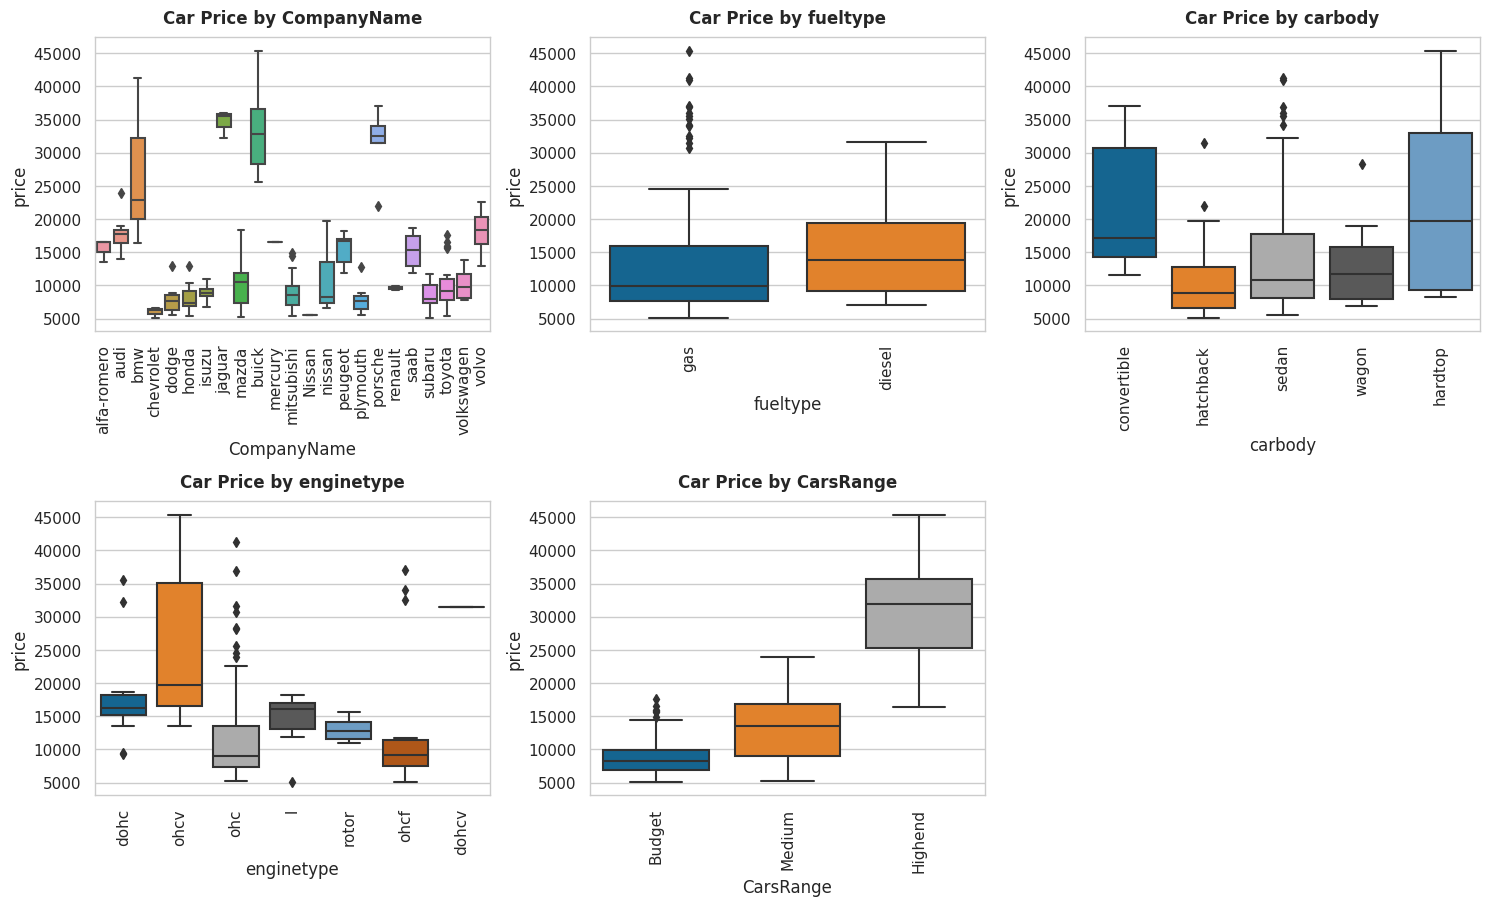

In [ ]:
k = 0
plt.figure(figsize=(15, 36))
columns=["CompanyName","fueltype","carbody","enginetype","CarsRange"]
for col in columns:
 plt.subplot(8, 3, k + 1)
 sns.boxplot(x=col,y="price",data=df)
 plt.xticks(rotation=90)
 plt.title(f"Car Price by {col}", pad=10, fontweight="black", fontsize=12)
 k += 1
plt.tight_layout()


**15.Elimine las columnas con alta cardinalidad excepto enginetype pues esta
característica tiene un alto impacto en nuestra variable objetivo**

In [ ]:
cat_cols = df.select_dtypes('object').columns
k = 0
cardinality_cols = []



for col in cat_cols:
    value_counts = df[col].value_counts(normalize=True).round(2)
    if len(value_counts) > 5 or len(value_counts) < 2:
        cardinality_cols.append(col)
    else:
        print("====================================================================")
        print(col)
        print(value_counts)



cardinality_cols.remove('enginetype')
print(f"Removed Columns: {cardinality_cols}")
df.drop(columns=cardinality_cols, axis=1, inplace=True)

fueltype
gas       0.9
diesel    0.1
Name: fueltype, dtype: float64
aspiration
std      0.82
turbo    0.18
Name: aspiration, dtype: float64
carbody
sedan          0.47
hatchback      0.34
wagon          0.12
hardtop        0.04
convertible    0.03
Name: carbody, dtype: float64
drivewheel
fwd    0.59
rwd    0.37
4wd    0.04
Name: drivewheel, dtype: float64
enginelocation
front    0.99
rear     0.01
Name: enginelocation, dtype: float64
Removed Columns: ['CompanyName', 'fuelsystem']


In [ ]:
df['enginetype'].value_counts(normalize=True).round(2)

ohc      0.72
ohcf     0.07
ohcv     0.06
dohc     0.06
l        0.06
rotor    0.02
dohcv    0.00
Name: enginetype, dtype: float64

**16.Elimine las columnas de varianza baja (ninguna, pero ejecute la prueba).**

In [ ]:
num_cols = df.select_dtypes('number').columns

low_var_cols = []
for col in num_cols:
    scaled = (df[col] - df[col].mean()) / df[col].std()
    variance = scaled.var().round(4)
    if variance == 0 or df[col].std() == 0:
        low_var_cols.append(col)
#     else:
#         print(col, variance)

df.drop(columns=low_var_cols, axis=1, inplace=True)
print(f"Removed Columns: {low_var_cols}")
print(df.shape, len(low_var_cols))

Removed Columns: []
(205, 26) 0


**17.Elimine las características que tienen una correlación mayor a 0.85**

In [ ]:
corr = dataframe.drop('price', axis=1).corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(np.bool_))
drop = [column for column in upper.columns if any(np.abs(upper[column]) > 0.85)]
print(f"columns dropped are: {drop}")
dataframe.drop(columns=drop, axis=1, inplace=True)

columns dropped are: ['carlength', 'curbweight', 'enginesize', 'highwaympg']


In [ ]:
print(df.columns.values)
df.shape

['car_ID' 'symboling' 'fueltype' 'aspiration' 'doornumber' 'carbody'
 'drivewheel' 'enginelocation' 'wheelbase' 'carlength' 'carwidth'
 'carheight' 'curbweight' 'enginetype' 'cylindernumber' 'enginesize'
 'boreratio' 'stroke' 'compressionratio' 'horsepower' 'peakrpm' 'citympg'
 'highwaympg' 'price' 'mean' 'CarsRange']


(205, 26)

**18.Convierta las columnas object a numéricas con el siguiente código:**

In [ ]:
cat_columns = df.select_dtypes(['object']).columns
print(cat_columns)
for c in cat_columns:
 df[c]= df[c].astype('category')
df[cat_columns] = df[cat_columns].apply(lambda x: x.cat.codes)


Index(['fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation',
       'enginetype'],
      dtype='object')


**19.La columna CarsRange para poder ser procesada por el modelo debería ser
codificada con one-hot, pero la convertiremos a número y le indicaremos al modelo
que es categórica (C)**

In [ ]:
gama=['Budget','Medium','Highend']
i=0
while i<3:
 df['CarsRange'].replace(gama[i],i,inplace=True)
 i=i+1
df['CarsRange']= df['CarsRange'].astype('int')

**20.Aplique las pruebas del factor de inflación de la varianza (VIF) para eliminar en cada
iteración la característica con el mayor coeficiente VIF hasta que todas queden con
un valor inferior a 5. Debe ignorar todas las columnas categóricas y también las
columnas 'horsepower' y 'carwidth' pues son de gran importancia para el modelo.**

In [ ]:
ignorecolumns=['price', 'fueltype', 'aspiration', 'carbody', 'drivewheel',
'enginetype', 'horsepower', 'carwidth']
X = df.drop(ignorecolumns,axis=1)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,5.9,car_ID
1,3.3,symboling
2,24.8,doornumber
3,1.8,enginelocation
4,2025.6,wheelbase
5,2012.9,carlength
6,1132.6,carheight
7,390.1,curbweight
8,131.1,cylindernumber
9,222.5,enginesize


In [ ]:
del df['mean']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,6.2,car_ID
1,4.1,symboling
2,783.4,fueltype
3,3.5,aspiration
4,31.0,doornumber
5,29.6,carbody
6,18.0,drivewheel
7,1.8,enginelocation
8,2921.1,wheelbase
9,2439.2,carlength


In [ ]:
del df['highwaympg']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,6.2,car_ID
1,4.0,symboling
2,783.2,fueltype
3,3.3,aspiration
4,30.3,doornumber
5,29.6,carbody
6,18.0,drivewheel
7,1.8,enginelocation
8,2883.9,wheelbase
9,2428.2,carlength


In [ ]:
del df['citympg']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,6.2,car_ID
1,3.9,symboling
2,694.1,fueltype
3,3.3,aspiration
4,30.2,doornumber
5,29.0,carbody
6,17.9,drivewheel
7,1.8,enginelocation
8,2879.0,wheelbase
9,2171.5,carlength


In [ ]:
del df['peakrpm']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,6.1,car_ID
1,3.9,symboling
2,634.0,fueltype
3,3.2,aspiration
4,30.1,doornumber
5,28.3,carbody
6,17.9,drivewheel
7,1.7,enginelocation
8,2871.7,wheelbase
9,2164.4,carlength


In [ ]:
del df['compressionratio']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,6.0,car_ID
1,3.8,symboling
2,24.6,fueltype
3,2.6,aspiration
4,30.1,doornumber
5,28.3,carbody
6,16.1,drivewheel
7,1.7,enginelocation
8,2823.1,wheelbase
9,2157.4,carlength


In [ ]:
del df['stroke']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,5.9,car_ID
1,3.8,symboling
2,23.9,fueltype
3,2.6,aspiration
4,30.1,doornumber
5,27.9,carbody
6,16.0,drivewheel
7,1.6,enginelocation
8,2760.9,wheelbase
9,2154.9,carlength


In [ ]:
del df['boreratio']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,5.5,car_ID
1,3.8,symboling
2,23.6,fueltype
3,2.6,aspiration
4,30.1,doornumber
5,27.9,carbody
6,15.7,drivewheel
7,1.6,enginelocation
8,2702.3,wheelbase
9,2154.7,carlength


In [ ]:
del df['enginesize']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,5.5,car_ID
1,3.8,symboling
2,23.3,fueltype
3,2.5,aspiration
4,30.1,doornumber
5,25.8,carbody
6,15.7,drivewheel
7,1.6,enginelocation
8,2569.0,wheelbase
9,2128.8,carlength


In [ ]:
del df['cylindernumber']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,5.5,car_ID
1,3.6,symboling
2,22.4,fueltype
3,2.0,aspiration
4,29.9,doornumber
5,25.8,carbody
6,14.5,drivewheel
7,1.6,enginelocation
8,2565.0,wheelbase
9,2038.6,carlength


In [ ]:
del df['curbweight']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,5.4,car_ID
1,3.6,symboling
2,18.5,fueltype
3,2.0,aspiration
4,29.8,doornumber
5,25.4,carbody
6,14.5,drivewheel
7,1.6,enginelocation
8,2393.0,wheelbase
9,1621.4,carlength


In [ ]:
del df['carheight']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,5.1,car_ID
1,3.6,symboling
2,17.6,fueltype
3,2.0,aspiration
4,29.6,doornumber
5,23.6,carbody
6,13.6,drivewheel
7,1.4,enginelocation
8,2251.0,wheelbase
9,1620.7,carlength


In [ ]:
del df['enginelocation']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,4.9,car_ID
1,3.6,symboling
2,17.5,fueltype
3,1.9,aspiration
4,28.9,doornumber
5,23.2,carbody
6,13.6,drivewheel
7,2233.4,wheelbase
8,1607.9,carlength
9,1519.9,carwidth


In [ ]:
del df['carlength']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,4.7,car_ID
1,3.4,symboling
2,17.5,fueltype
3,1.9,aspiration
4,27.4,doornumber
5,22.5,carbody
6,13.6,drivewheel
7,1459.1,wheelbase
8,1458.8,carwidth
9,10.4,enginetype


In [ ]:
del df['wheelbase']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,4.7,car_ID
1,2.8,symboling
2,17.5,fueltype
3,1.9,aspiration
4,27.2,doornumber
5,21.4,carbody
6,11.9,drivewheel
7,85.8,carwidth
8,9.9,enginetype
9,19.2,horsepower


In [ ]:
del df['car_ID']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,2.8,symboling
1,17.1,fueltype
2,1.9,aspiration
3,26.5,doornumber
4,21.4,carbody
5,11.8,drivewheel
6,83.7,carwidth
7,9.9,enginetype
8,18.9,horsepower
9,3.5,CarsRange


In [ ]:
del df['symboling']
X = df.drop('price',axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,16.9,fueltype
1,1.9,aspiration
2,21.3,doornumber
3,19.7,carbody
4,11.4,drivewheel
5,61.7,carwidth
6,9.8,enginetype
7,18.8,horsepower
8,3.5,CarsRange


**23.Separe los datos en 80% entrenamiento y 20% pruebas (Xtrain, Xtest, Ytrain, Ytest)**

In [ ]:
print(df.columns)
df.shape

Index(['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
       'carwidth', 'enginetype', 'horsepower', 'price', 'CarsRange'],
      dtype='object')


(205, 10)

In [ ]:
df.head()

,fueltype,aspiration,doornumber,carbody,drivewheel,carwidth,enginetype,horsepower,price,CarsRange
0,1,0,2,0,2,64.1,0,111,13495.0,1
1,1,0,2,0,2,64.1,0,111,16500.0,1
2,1,0,2,2,2,65.5,5,154,16500.0,1
3,1,0,4,3,1,66.2,3,102,13950.0,1
4,1,0,4,3,0,66.4,3,115,17450.0,1


In [ ]:
X = df.drop('price',axis=1)
Y = df['price']
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y.values.reshape(-1,1),test_size=0.20, random_state=42)

**24.Cree el modelo de regresión lineal múltiple utilizando el modo fórmula**

In [ ]:
# Creación del modelo utilizando el modo fórmula (similar a R)
# ==============================================================================
datos_train = pd.DataFrame(
                     np.hstack((Xtrain, Ytrain)),
                     columns=np.append(Xtrain.columns.values,'price')
               )
modelo = smf.ols(formula = 'price ~ fueltype+doornumber+carwidth+horsepower+'+'aspiration+carbody+drivewheel+enginetype+CarsRange', data = datos_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     106.2
Date:                Fri, 07 Jul 2023   Prob (F-statistic):           2.01e-61
Time:                        04:01:27   Log-Likelihood:                -1538.8
No. Observations:                 164   AIC:                             3098.
Df Residuals:                     154   BIC:                             3129.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -5.497e+04   1.05e+04     -5.245      0.0

**25.Mejore el modelo utilizando como variables categóricas las columnas: aspiration,
carbody, drivewheel, enginetype y CarsRange**

In [ ]:
# Creación del modelo utilizando el modo fórmula (similar a R)
# ==============================================================================
datos_train = pd.DataFrame(
                     np.hstack((Xtrain, Ytrain)),
                     columns=np.append(Xtrain.columns.values,'price')
               )
modelo = smf.ols(formula = 'price ~ fueltype+doornumber+carwidth+horsepower+'+'C(aspiration)+C(carbody)+C(drivewheel)+C(enginetype)+C(CarsRange)', data = datos_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     117.5
Date:                Fri, 07 Jul 2023   Prob (F-statistic):           1.16e-77
Time:                        04:01:27   Log-Likelihood:                -1471.0
No. Observations:                 164   AIC:                             2982.
Df Residuals:                     144   BIC:                             3044.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -6.803e+04 

**26.Elimine del modelo las características que son insignificantes por su p-value >0.05.**

In [ ]:
# Creación del modelo utilizando el modo fórmula (similar a R)
# ==============================================================================
datos_train = pd.DataFrame(
                     np.hstack((Xtrain, Ytrain)),
                     columns=np.append(Xtrain.columns.values,'price')
               )
modelo = smf.ols(formula = 'price ~ fueltype+carwidth+horsepower+'+'carbody+enginetype+CarsRange', data = datos_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.851
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     149.3
Date:                Fri, 07 Jul 2023   Prob (F-statistic):           3.14e-62
Time:                        04:25:15   Log-Likelihood:                -1544.8
No. Observations:                 164   AIC:                             3104.
Df Residuals:                     157   BIC:                             3125.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -5.879e+04   1.06e+04     -5.529      0.0

In [ ]:
# Creación del modelo utilizando el modo fórmula (similar a R)
# ==============================================================================
datos_train = pd.DataFrame(
                     np.hstack((Xtrain, Ytrain)),
                     columns=np.append(Xtrain.columns.values,'price')
               )
modelo = smf.ols(formula = 'price ~ fueltype+carwidth+horsepower+'+'C(carbody)+C(enginetype)+C(CarsRange)', data = datos_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.931
Method:                 Least Squares   F-statistic:                     147.5
Date:                Fri, 07 Jul 2023   Prob (F-statistic):           6.94e-81
Time:                        04:28:07   Log-Likelihood:                -1473.7
No. Observations:                 164   AIC:                             2979.
Df Residuals:                     148   BIC:                             3029.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -7.222e+04 

**27.Realice el diagnostico de errores (residuos) de las predicciones del entrenamiento y
realice los gráficos correspondientes**

In [ ]:
# Diagnóstico errores (residuos) de las predicciones de entrenamiento
# ==============================================================================
Ytrain = Ytrain.flatten()
prediccion_train = modelo.predict(exog = Xtrain)
residuos_train   = prediccion_train - Ytrain

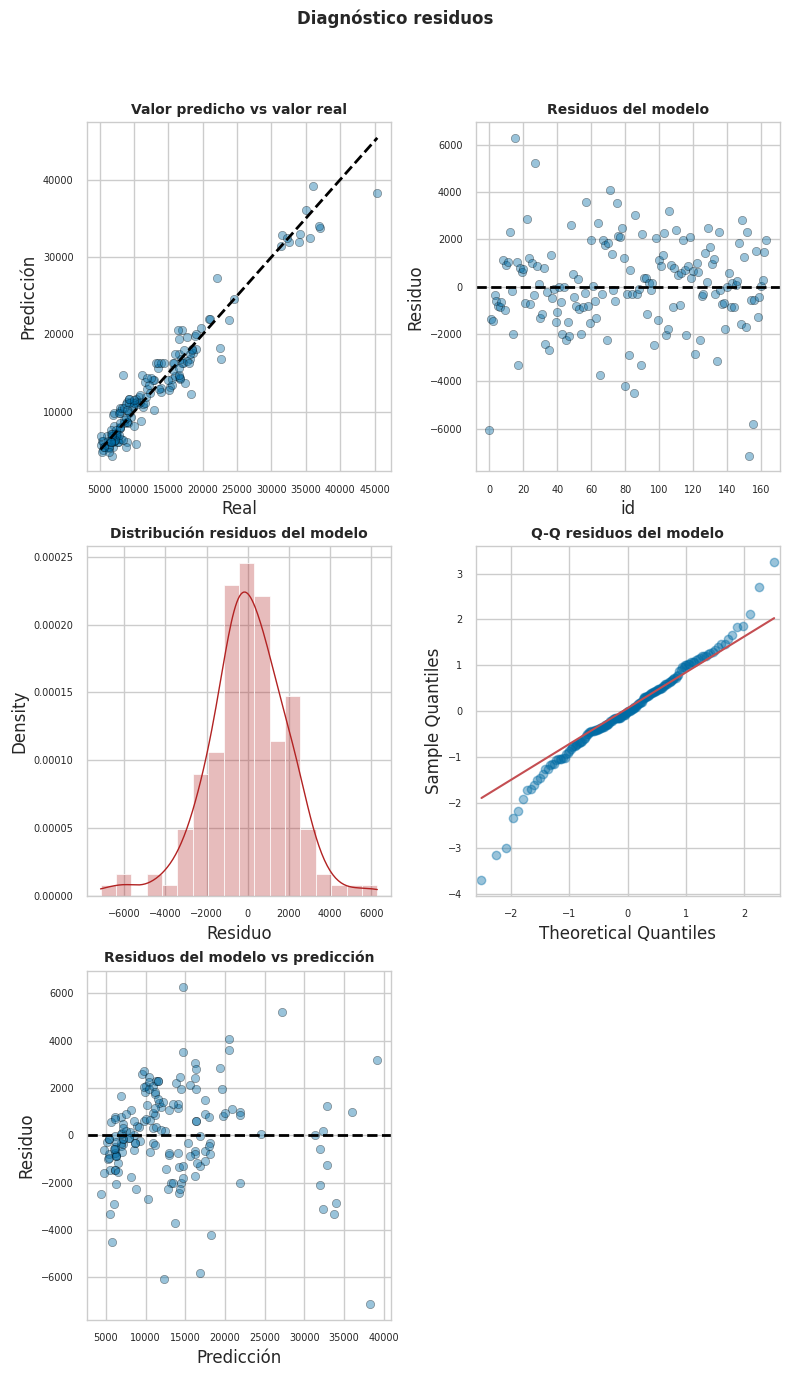

In [ ]:
# Gráficos
# ==============================================================================
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(8, 14))



axes[0, 0].scatter(Ytrain, prediccion_train, edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 0].plot([Ytrain.min(), Ytrain.max()], [Ytrain.min(), Ytrain.max()],
                'k--', color = 'black', lw=2)
axes[0, 0].set_title('Valor predicho vs valor real', fontsize = 10, fontweight = "bold")
axes[0, 0].set_xlabel('Real')
axes[0, 0].set_ylabel('Predicción')
axes[0, 0].tick_params(labelsize = 7)



axes[0, 1].scatter(list(range(len(Ytrain))), residuos_train,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[0, 1].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[0, 1].set_title('Residuos del modelo', fontsize = 10, fontweight = "bold")
axes[0, 1].set_xlabel('id')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].tick_params(labelsize = 7)



sns.histplot(
    data    = residuos_train,
    stat    = "density",
    kde     = True,
    line_kws= {'linewidth': 1},
    color   = "firebrick",
    alpha   = 0.3,
    ax      = axes[1, 0]
)



axes[1, 0].set_title('Distribución residuos del modelo', fontsize = 10,
                     fontweight = "bold")
axes[1, 0].set_xlabel("Residuo")
axes[1, 0].tick_params(labelsize = 7)




sm.qqplot(
    residuos_train,
    fit   = True,
    line  = 'q',
    ax    = axes[1, 1],
    color = 'firebrick',
    alpha = 0.4,
    lw    = 2
)
axes[1, 1].set_title('Q-Q residuos del modelo', fontsize = 10, fontweight = "bold")
axes[1, 1].tick_params(labelsize = 7)



axes[2, 0].scatter(prediccion_train, residuos_train,
                   edgecolors=(0, 0, 0), alpha = 0.4)
axes[2, 0].axhline(y = 0, linestyle = '--', color = 'black', lw=2)
axes[2, 0].set_title('Residuos del modelo vs predicción', fontsize = 10, fontweight = "bold")
axes[2, 0].set_xlabel('Predicción')
axes[2, 0].set_ylabel('Residuo')
axes[2, 0].tick_params(labelsize = 7)



# Se eliminan los axes vacíos
fig.delaxes(axes[2,1])



fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Diagnóstico residuos', fontsize = 12, fontweight = "bold");
plt.show()

**28.Verifique la normalidad de los residuos con el test Shapiro-Wilk y con D'Agostino's K-squared**

In [ ]:
# Normalidad de los residuos Shapiro-Wilk test

# ==============================================================================

shapiro_test = stats.shapiro(residuos_train)

shapiro_test

# Normalidad de los residuos D'Agostino's K-squared test

# ==============================================================================

k2, p_value = stats.normaltest(residuos_train)

print(f"Estadítico= {k2}, p-value = {p_value}")

Estadítico= 12.443371125717182, p-value = 0.001985895043667593


**29.Calcule el rmse con los datos de prueba (Xtest)**

In [ ]:
# Error de test del modelo
# ==============================================================================
Xtest = sm.add_constant(Xtest, prepend=True)
predicciones = modelo.predict(exog = Xtest)
rmse = mean_squared_error(
        y_true  = Ytest,
        y_pred  = predicciones,
        squared = False
       )
print("")
print(f"El error (rmse) de test es: {rmse}")


El error (rmse) de test es: 3176.527965832029


**30.Escriba la formula del modelo resultante. (markdown en el notebook**

In [ ]:
price=-6.803e+04-2248.2192*10 -1737.3386*10+960.1840*10+ 89.3213*10-753.8412*10 + 99.0995*10  + 1263.0787*10 + 393.9730*10 + 1201.2132 *10 + 3614.0325*10
print(price)

-39214.96800000001
